In [ ]:
import sys
sys.path.append('..')
from osp import *


In [28]:
df_feats = pd.read_pickle('../data/raw/df_feats.pkl.gz')
df_feats.drop(columns=['weight','run'], inplace=True)
df_feats = df_feats.groupby('feature').mean(numeric_only=True).reset_index()
df_feats['feature'] = df_feats['feature'].apply(lambda x: f'{FEAT2DESC[x]} ({x.split("_")[0]})')
df_feats = df_feats.set_index('feature')

In [29]:
phil_avg = df_feats[[c for c in df_feats.columns if 'Philosophy' in c]].mean(axis=1) * -1
phil_avg

feature
Clausal modifier of noun (adnominal clause) (deprel)   -0.025772
Relative clause modifier (deprel)                      -0.207252
Adverbial clause modifier (deprel)                     -0.131739
Adverbial relative clause modifier (deprel)            -0.006931
Adverbial modifier (deprel)                            -0.246610
                                                          ...   
Type-token ratio for adjectives (ttr)                   0.093516
Type-token ratio for adverbs (ttr)                     -0.014100
Type-token ratio for nouns (ttr)                        0.130816
Type-token ratio for verbs (ttr)                       -0.016313
Mean type-token ratio (ttr)                             0.183755
Length: 99, dtype: float64

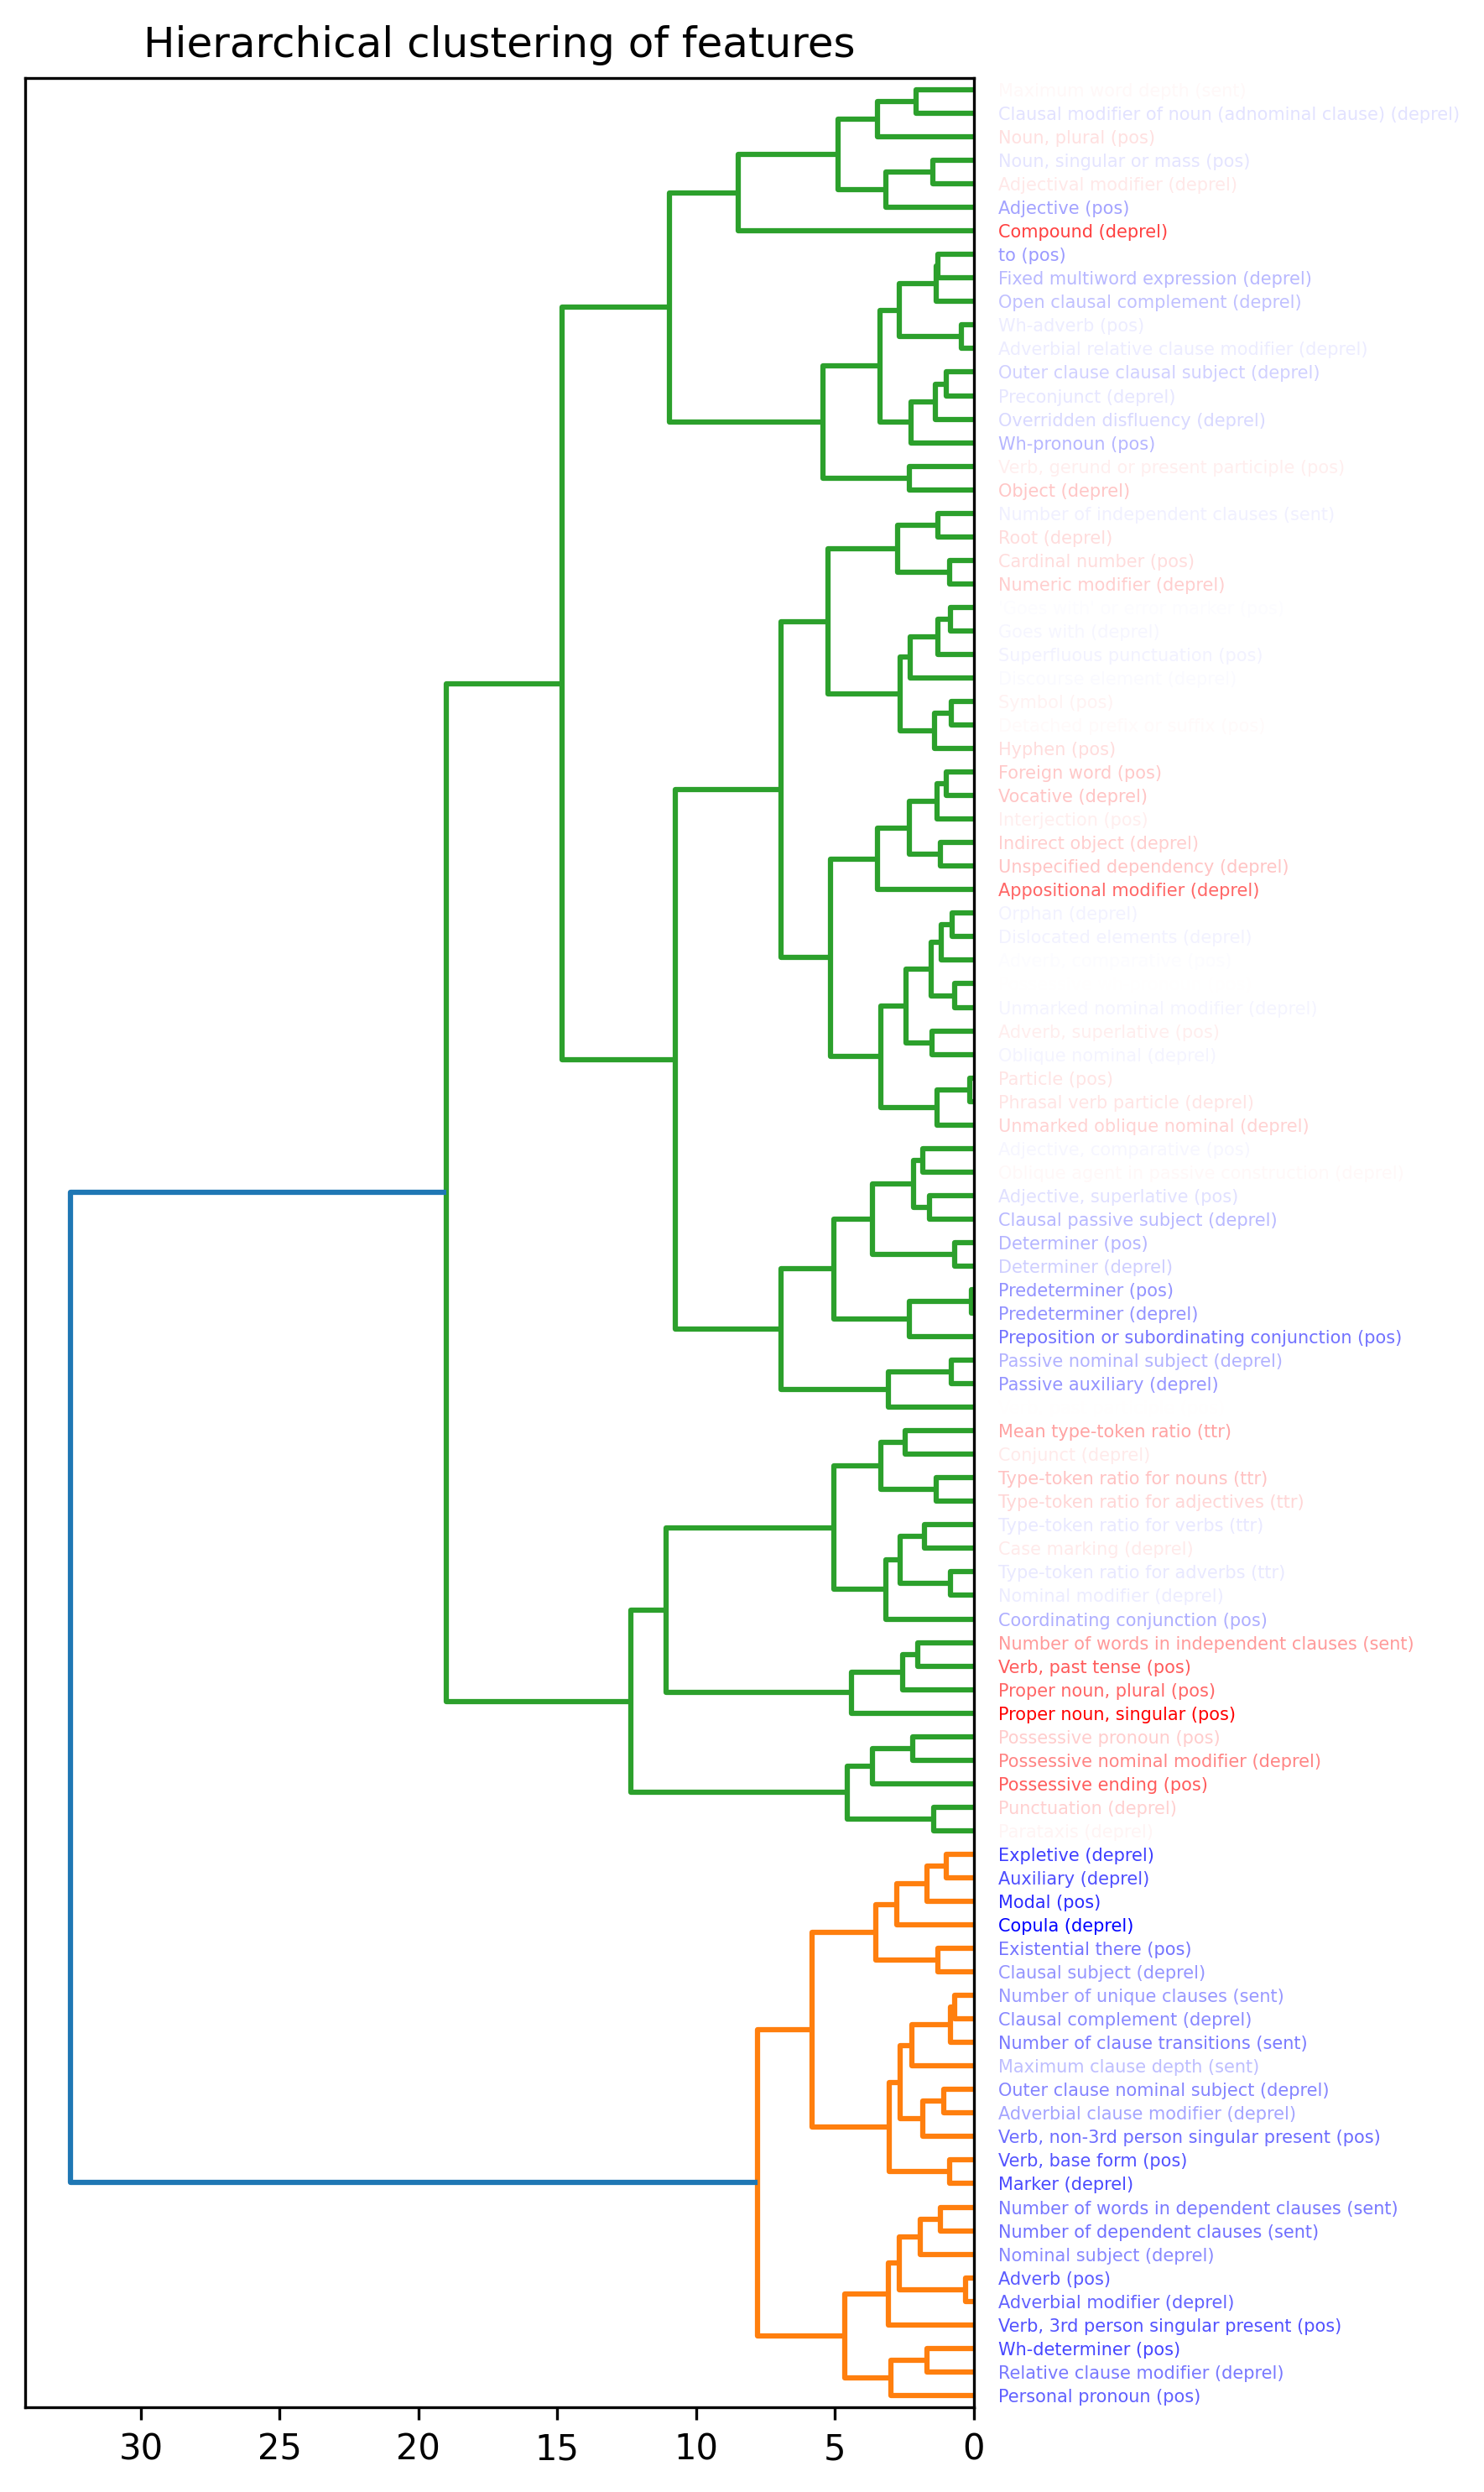

In [31]:
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib as mpl

# Assume df_feats and phil_avg are already defined

# Optional: scale features (recommended for clustering)
X = StandardScaler().fit_transform(df_feats.values)

# Compute linkage (method can be "ward", "average", "complete", etc.)
Z = linkage(X, method="ward")

# Prepare colors: map phil_avg to color (red-negative to blue-positive)
norm = mpl.colors.Normalize(vmin=phil_avg.min(), vmax=phil_avg.max())
cmap = plt.cm.bwr  # blue-white-red; can use 'coolwarm', or define own
label_colors = {idx: mpl.colors.rgb2hex(cmap(norm(val))) for idx, val in phil_avg.items()}

# Plot dendrogram vertically with DPI 300
fig = plt.figure(figsize=(6, 10), dpi=300)
ddata = dendrogram(
    Z,
    labels=df_feats.index.astype(str).to_list(),
    orientation="left",
    leaf_rotation=0,
)

# Color leaf labels
ax = plt.gca()
xlabs = ax.get_yticklabels()
leaves = ddata.get('ivl', [])
for lbl, fname in zip(xlabs, leaves):
    color = label_colors.get(fname, '#000000')
    lbl.set_color(color)

plt.title("Hierarchical clustering of features")
# Removed colorbar legend for phil_avg
plt.savefig("../figures/feature_clustering_dendrogram.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()